# Milestone 2 — Dynamic World: can we trust it, and what is it good for here?

Greenness can't tell trees from crops, grass or scrub (gotcha 3). Google's Dynamic World labels every
10 m Sentinel-2 pixel as one of nine classes: water, trees, grass, flooded vegetation, crops, shrub &
scrub, built, bare, snow. A first cut on the 40 biggest-loss hexes read built-up going from 36.5% to
67.3% of their land between 2019 and 2026, with trees, scrub and crops making up the loss. Before
building anything on that, this notebook tests it.

1. **Does it call cleared soil "built"?** The Shivaram Karanth Layout was scraped to bare red soil
   in 2024 with few buildings. If Dynamic World labels that "built", the first cut overstated things.
2. **Known-answer places:** Lalbagh, Varthur Lake, Hesaraghatta, the city centre, and the deep-dive
   hexes, each against what the photos and our own history say.
3. **The noise floor:** the same 2019→2026 comparison on hexes whose greenness didn't move. A class
   shift in the loss hexes means something only if it is well above what stable ground shows.
4. **How the season is combined:** the most common label across Feb–Mar against the average of the
   class probabilities.
5. **A second opinion:** ESA WorldCover 2021, a separate 10 m product, on a random sample of points.

Agreement with our greenness numbers is deliberately *not* used as validation: Dynamic World is
computed from the same Sentinel-2 pixels, so it would agree by construction.

**Needs Earth Engine.** Every request has a 2-minute deadline and retries (see the 2026-09-23 log).

In [1]:
import io
import json
import os
import socket
import urllib.request
from pathlib import Path

import ee
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from shapely.geometry import box as shapely_box

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

DW = "GOOGLE/DYNAMICWORLD/V1"
S2 = "COPERNICUS/S2_SR_HARMONIZED"
CLASSES = ["water", "trees", "grass", "flooded_vegetation", "crops", "shrub_and_scrub", "built", "bare",
           "snow_and_ice"]
SHORT = ["water", "trees", "grass", "flooded veg", "crops", "scrub", "built", "bare", "snow"]
DW_PALETTE = ["#419BDF", "#397D49", "#88B053", "#7A87C6", "#E49635", "#DFC35A", "#C4281B", "#A59B8F",
              "#B39FE1"]
RGB_MAX = 3000
TOP = 40

old = pd.read_csv("results/m2_hex_table.csv")
new = pd.read_csv("results/m2_hex_table_masked.csv")
land = new.groupby("h3").n_pixels.median() / old.groupby("h3").n_pixels.median()
green = new.pivot(index="h3", columns="year", values="green")
YEARS = list(green.columns)
norm = green.sub(green.mean(axis=0), axis=1)
change = (norm[YEARS[-1]] - norm[YEARS[0]])[land >= 0.25]
losses = change.nsmallest(TOP).index

grid = gpd.read_file("data/hex_grid.geojson").set_index("h3")
osm = gpd.read_file("data/osm_water.geojson")
masked_water = osm[osm["class"] != "wetland"]
sites = gpd.read_file("data/osm_sites.geojson").set_index("site")

socket.setdefaulttimeout(120)
ee.Initialize(project=os.environ["EE_PROJECT"])
ee.data.setDeadline(120_000)


def retry(fetch, tries=4):
    for attempt in range(tries):
        try:
            return fetch()
        except Exception as exc:
            if attempt == tries - 1:
                raise
            print(f"  retrying after {type(exc).__name__}")


def ee_geom(shapely_geom):
    return ee.Geometry(shapely_geom.__geo_interface__)


def hex_fc(ids):
    return ee.FeatureCollection([ee.Feature(ee_geom(grid.geometry[h]), {"h3": h}) for h in ids])


def water_mask(shapely_area):
    lakes = masked_water[masked_water.intersects(shapely_area)]
    if lakes.empty:
        return ee.Image.constant(1)
    return ee.Image.constant(1).paint(ee.FeatureCollection([ee.Feature(ee_geom(g)) for g in lakes.geometry]), 0)


def season(year, region):
    return ee.ImageCollection(DW).filterBounds(region).filterDate(f"{year}-02-01", f"{year}-03-31")


def label_mode(year, region):
    return season(year, region).select("label").mode()


def label_from_mean_probability(year, region):
    return season(year, region).select(CLASSES).mean().toArray().arrayArgmax().arrayGet([0]).rename("label")


def class_shares(image, fc):
    res = retry(image.reduceRegions(collection=fc, reducer=ee.Reducer.frequencyHistogram(), scale=10).getInfo)
    total = {}
    for f in res["features"]:
        for k, v in (f["properties"].get("histogram") or {}).items():
            name = SHORT[int(float(k))]
            total[name] = total.get(name, 0) + v
    s = sum(total.values())
    return pd.Series({k: v / s for k, v in total.items()}).reindex(SHORT).fillna(0)


def thumb(image, region, fmt, px=240):
    def fetch():
        url = image.getThumbURL({"region": region, "dimensions": px, "format": fmt})
        return plt.imread(io.BytesIO(urllib.request.urlopen(url).read()), format=fmt)
    return retry(fetch)


def pct(frame):
    return frame.map(lambda v: f"{v:.0%}" if abs(v) >= 0.005 else "")


print(f"{len(losses)} loss hexes; Earth Engine ready")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


40 loss hexes; Earth Engine ready


---
## 1 — Does Dynamic World call cleared soil "built"?

Four hexes in the Shivaram Karanth Layout, the biggest loss cluster: hex B (`88601696e3fffff`) and
ranks 4, 7 and 12 of the loss list. The photos show farmland until 2023, then scraped red soil and a
road grid from 2024, with few buildings by 2026. The table below is Dynamic World's view of their
combined land, year by year. The strip shows hex B's photos beside its Dynamic World labels.

Shivaram Karanth Layout, 4 hexes: Dynamic World share of land by year (Feb-Mar mode)
      2019 2020 2021 2022 2023 2024 2025 2026
crops   9%   8%  13%  22%  24%   1%   4%   1%
scrub  40%  30%  20%  17%  21%  60%  34%   3%
trees  23%  29%  30%  25%  20%               
grass                                        
bare                            15%   4%   1%
built  28%  33%  37%  35%  35%  23%  58%  95%


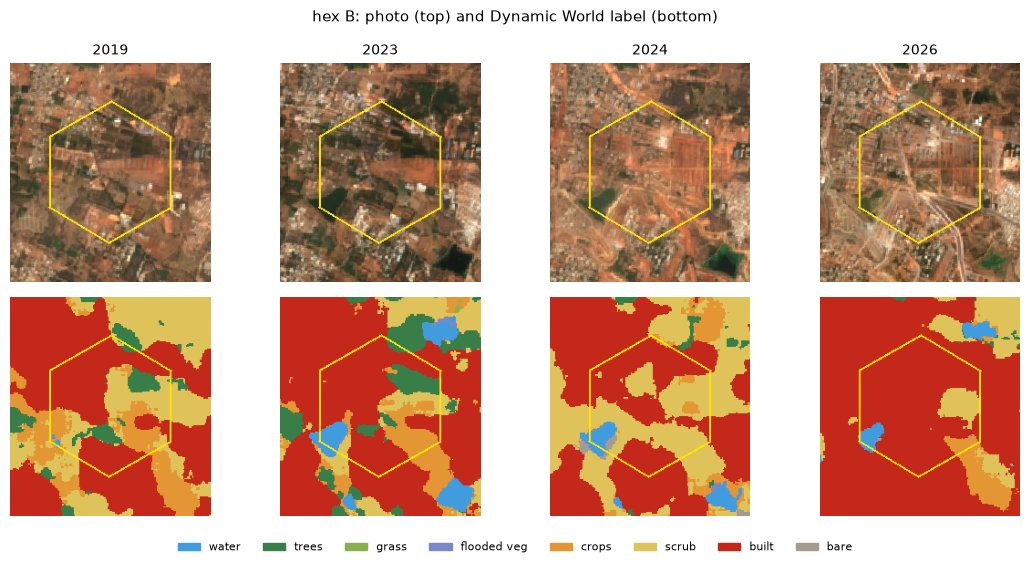

In [2]:
layout = ["88601696e3fffff", "8860169685fffff", "8860169681fffff", "8860169683fffff"]
layout_area = grid.loc[layout].union_all()
mask = water_mask(layout_area.buffer(0.01))
fc = hex_fc(layout)
by_year = pd.DataFrame({y: class_shares(label_mode(y, fc).updateMask(mask), fc) for y in YEARS})
print("Shivaram Karanth Layout, 4 hexes: Dynamic World share of land by year (Feb-Mar mode)")
print(pct(by_year.loc[["crops", "scrub", "trees", "grass", "bare", "built"]]).to_string())

hb = ee_geom(grid.geometry["88601696e3fffff"])
region = hb.buffer(300).bounds()
edge = ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(hb)]), 1, 2).selfMask().visualize(palette=["#ffe600"])
show = [YEARS[0], 2023, 2024, YEARS[-1]]
fig, axes = plt.subplots(2, len(show), figsize=(11, 5.6))
for i, year in enumerate(show):
    s2 = ee.ImageCollection(S2).filterBounds(region).filterDate(f"{year}-02-01", f"{year}-03-31").median()
    axes[0][i].imshow(thumb(s2.visualize(bands=["B4", "B3", "B2"], min=0, max=RGB_MAX).blend(edge), region, "jpg"))
    axes[1][i].imshow(thumb(label_mode(year, region).visualize(min=0, max=8, palette=DW_PALETTE).blend(edge),
                            region, "png"))
    axes[0][i].set_title(str(year), fontsize=10)
    for ax in axes[:, i]:
        ax.set_axis_off()
fig.legend(handles=[Patch(color=c, label=n) for c, n in zip(DW_PALETTE[:8], SHORT[:8])],
           loc="lower center", ncol=8, fontsize=8, frameon=False)
fig.suptitle("hex B: photo (top) and Dynamic World label (bottom)", fontsize=11)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

---
## 2 — Known-answer places

Each place has an expected answer from something other than Dynamic World: the photos, OSM, or the
M1 history. Lakes and water sites are **not** masked here, since the point is to see what Dynamic
World does with water.

In [3]:
known = {
    "Lalbagh (mature park)": (sites.geometry["lalbagh"], "trees, every year"),
    "Varthur Lake": (sites.geometry["varthur_lake"], "hyacinth 2017-20, open water by 2026"),
    "Hesaraghatta Lake bed": (osm[osm.osm == "w41662659"].geometry.iloc[0], "dry to 2021, ~half water from 2023"),
    "Hesaraghatta Grass Farm hex": (grid.geometry["88601694b1fffff"], "grass"),
    "MG Road hex (city centre)": (grid.geometry[h3.latlng_to_cell(12.9755, 77.6067, 8)], "built, every year"),
    "hex C (Bellandur edge + sewage plant)": (grid.geometry["8861892501fffff"], "marsh, dug up 2021 and 2024"),
}
rows = []
for name, (geom, expected) in known.items():
    fc = ee.FeatureCollection([ee.Feature(ee_geom(geom))])
    for y in YEARS:
        s = class_shares(label_mode(y, fc), fc)
        top2 = s.sort_values(ascending=False).head(2)
        rows.append({"place": name, "expected": expected, "year": y,
                     "Dynamic World": " / ".join(f"{k} {v:.0%}" for k, v in top2.items() if v >= 0.05)})
known_table = pd.DataFrame(rows).pivot(index=["place", "expected"], columns="year", values="Dynamic World")
pd.set_option("display.max_colwidth", 40)
print(known_table.T.to_string())

place    Hesaraghatta Grass Farm hex              Hesaraghatta Lake bed  Lalbagh (mature park) MG Road hex (city centre)                         Varthur Lake hex C (Bellandur edge + sewage plant)
expected                       grass dry to 2021, ~half water from 2023      trees, every year         built, every year hyacinth 2017-20, open water by 2026           marsh, dug up 2021 and 2024
year                                                                                                                                                                                               
2019           scrub 85% / trees 15%              scrub 41% / trees 22%  trees 45% / built 31%      built 83% / trees 9%                water 37% / crops 24%                 built 42% / grass 33%
2020           scrub 61% / trees 39%              scrub 45% / trees 30%  trees 41% / built 35%      built 84% / trees 7%                crops 50% / grass 28%                 built 43% / crops 22%
2021           scrub

---
## 3 — The noise floor

The same 2019→2026 class comparison on **stable hexes**: greenness change under 0.02 in either
direction, over 90% land, and no mapped water or wetland. That is a random sample of 200, since the
full set is large. If Dynamic World were perfectly consistent, these would show almost no class
change.

The second measure is **flicker**: for each pixel, how many of the seven year-to-year steps change its
label, averaged over the group. Stable ground should flicker little. A real one-off clearing adds at
most one change per pixel.

In [4]:
clean = 1 - (gpd.overlay(grid.reset_index()[["h3", "geometry"]], osm[["geometry"]])
             .dissolve(by="h3").area.div(grid.geometry.area).reindex(grid.index).fillna(0))
stable_pool = change[(change.abs() < 0.02) & (land.reindex(change.index) > 0.9)
                     & (clean.reindex(change.index) >= 0.999)].index
stable = pd.Index(pd.Series(stable_pool).sample(200, random_state=7))
print(f"stable pool: {len(stable_pool):,} hexes; sampled 200")

groups = {"40 biggest losses": losses, "200 stable hexes": stable}
shift, flicker = {}, {}
for label, ids in groups.items():
    area = grid.loc[ids].union_all()
    mask = water_mask(area.buffer(0.01))
    fc = hex_fc(ids)
    a = class_shares(label_mode(YEARS[0], fc).updateMask(mask), fc)
    b = class_shares(label_mode(YEARS[-1], fc).updateMask(mask), fc)
    shift[label] = b - a
    stack = ee.Image.cat([label_mode(y, fc) for y in YEARS])
    flips = ee.Image.cat([stack.select(i).neq(stack.select(i + 1)) for i in range(len(YEARS) - 1)]) \
        .reduce(ee.Reducer.sum()).updateMask(mask)
    res = retry(flips.reduceRegions(collection=fc, reducer=ee.Reducer.mean(), scale=10).getInfo)
    flicker[label] = pd.Series([f["properties"].get("mean") for f in res["features"]]).mean()

shift_table = pd.DataFrame(shift).loc[["built", "trees", "crops", "scrub", "grass", "bare"]]
print(f"\nchange in share of land, {YEARS[0]} -> {YEARS[-1]} (percentage points)")
print(shift_table.map(lambda v: f"{v * 100:+.1f}").to_string())
print(f"\naverage label changes per pixel over the {len(YEARS) - 1} year-to-year steps:")
for label, v in flicker.items():
    print(f"  {label:<20} {v:.2f}")

/var/folders/3b/qkc70gt14nq1b_tc9cyhgcjm0000gn/T/ipykernel_70446/1397869045.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  .dissolve(by="h3").area.div(grid.geometry.area).reindex(grid.index).fillna(0))


stable pool: 722 hexes; sampled 200



change in share of land, 2019 -> 2026 (percentage points)
      40 biggest losses 200 stable hexes
built             +30.8             +9.1
trees             -12.4             +1.7
crops              -9.2             -1.1
scrub             -10.0             -9.5
grass              -1.9             +0.0
bare               +3.3             -0.2

average label changes per pixel over the 7 year-to-year steps:
  40 biggest losses    1.89
  200 stable hexes     0.88


---
## 4 — Most common label, or average probability?

Dynamic World gives a label *and* a probability for each class, for every image. The first cut took
the most common label across Feb–Mar. The alternative averages each class's probability across the
same images and takes the highest. Same 40 loss hexes, both ways.

In [5]:
fc = hex_fc(losses)
mask = water_mask(grid.loc[losses].union_all().buffer(0.01))
compare = {}
for y in (YEARS[0], YEARS[-1]):
    compare[f"{y} mode"] = class_shares(label_mode(y, fc).updateMask(mask), fc)
    compare[f"{y} mean prob"] = class_shares(label_from_mean_probability(y, fc).updateMask(mask), fc)
compare = pd.DataFrame(compare).loc[["built", "trees", "crops", "scrub", "grass", "bare"]]
print(pct(compare).to_string())
print("\nlargest gap between the two methods, in percentage points:",
      f"{(compare.filter(like='mode').values - compare.filter(like='mean').values).__abs__().max() * 100:.1f}")

      2019 mode 2019 mean prob 2026 mode 2026 mean prob
built       37%            37%       67%            68%
trees       23%            22%       10%            10%
crops       22%            22%       13%            13%
scrub       15%            15%        5%             5%
grass        2%             2%                         
bare         1%             1%        4%             4%

largest gap between the two methods, in percentage points: 0.6


---
## 5 — A second opinion: ESA WorldCover 2021

WorldCover (`ESA/WorldCover/v200`) is a separate 10 m land-cover map for 2021, made by ESA with a
different method. On 3,000 random points across the study area, it's compared with Dynamic World's
Feb–Mar 2021 mode. The classes are mapped one-to-one: tree cover → trees, shrubland → scrub,
grassland → grass, cropland → crops, built-up → built, bare/sparse → bare, permanent water → water,
herbaceous wetland → flooded vegetation. This is agreement between two maps, not accuracy against
the ground. WorldCover has its own errors.

In [6]:
WC = {10: "trees", 20: "scrub", 30: "grass", 40: "crops", 50: "built", 60: "bare", 80: "water",
      90: "flooded veg"}
study = gpd.read_file("data/study_boundary.geojson").geometry.iloc[0]
region = ee_geom(study)
points = ee.FeatureCollection.randomPoints(region, 3000, 11)
stack = label_mode(2021, region).rename("dw").addBands(
    ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").rename("wc"))
res = retry(stack.sampleRegions(collection=points, scale=10, geometries=False).getInfo)
pairs = pd.DataFrame([f["properties"] for f in res["features"]]).dropna()
pairs["dw"] = pairs.dw.astype(int).map(dict(enumerate(SHORT)))
pairs["wc"] = pairs.wc.astype(int).map(WC)
pairs = pairs.dropna()
conf = pd.crosstab(pairs.wc, pairs.dw, rownames=["WorldCover"], colnames=["Dynamic World"])
print(f"{len(pairs):,} points; overall agreement {(pairs.wc == pairs.dw).mean():.0%}\n")
print(conf.to_string())
per_class = pd.DataFrame({
    "points (WorldCover)": pairs.wc.value_counts(),
    "Dynamic World agrees": pairs[pairs.wc == pairs.dw].wc.value_counts(),
}).fillna(0)
per_class["agreement"] = (per_class["Dynamic World agrees"] / per_class["points (WorldCover)"]).map("{:.0%}".format)
print()
print(per_class.sort_values("points (WorldCover)", ascending=False).to_string())

3,000 points; overall agreement 53%

Dynamic World  bare  built  crops  flooded veg  grass  scrub  trees  water
WorldCover                                                                
bare              9     34      1            0      0      4      0      0
built             2    896      7            1      0      3      5      1
crops             4    274    301            2     15    251     73      3
grass             4     72     24            1      5     61      8      4
scrub             0     89     54            3      2    106    152      4
trees             0    202     29            2      4     12    242      3
water             0      0      0            0      0      1      1     29

       points (WorldCover)  Dynamic World agrees agreement
wc                                                        
crops                  923                   301       33%
built                  915                   896       98%
trees                  494                   242   

---
## What this shows

**Dynamic World can say "the vegetation here disappeared". It can't say what the vegetation was, and
it can't say the land was built on. It is not used in this project.** Decided 2026-09-27.

| question | answer | evidence |
|---|---|---|
| does it call cleared soil "built"? | **yes** | Shivaram Karanth Layout: 95% built by 2026, while the photos show scraped soil and a road grid with few buildings (section 1). "Built" means "cleared or built" |
| does it get known places right? | **partly** | MG Road and Lalbagh hold steady every year. The Hesaraghatta Grass Farm is never grass: scrub, then 54-63% trees. Varthur's hyacinth years read as crops (section 2) |
| is a change above what stable ground shows? | **for trees and crops, yes; for built, only partly** | stable hexes gain 9 points of built and lose 10 of scrub with no real change; the label flips about once per pixel over seven years even there (section 3) |
| does the way the season is combined matter? | **no** | mode and mean probability agree to 0.6 points (section 4) |
| does a second land-cover map agree? | **on built and water, yes; on the vegetation classes, no** | against ESA WorldCover 2021: built 98%, water 94%, trees 49%, crops 33%, scrub 26%, grass 3% (section 5) |

**Trees only, city-wide (2026-09-27).** The one class that could carry the "this area had trees and
now has few" story was measured for every hex (`measure_trees.py` → `results/m2_hex_trees.csv`,
same hexes, years and water mask as the greenness table). It did not hold up as a second method:

- moving the start year by one replaces 23 of the tree top 40; greenness keeps 32 of 40 under the
  same test;
- 20 of the tree top 40 sit on the Hoskote side (8% of hexes), driven by a 2019 reading there that
  no other part of the city shows, and not by missing images;
- photos of five top tree losses: one bushland clearing, one partly real, two unclear, one with no
  visible change. None showed canopy being cut. Its tree patches are smooth blobs that don't follow
  anything visible at 10 m;
- it gives the Hesaraghatta farm plots the same false gain greenness does (2% trees to 20%), so it
  doesn't fix gotcha 3, which is what it was brought in for.

The details are in the 2026-09-27 entries of `PROJECT.md`'s decision log. Crop swings and lake
edges are handled by eye in the photo checks instead.